In [1]:
!pip install sentence-transformers matplotlib seaborn


In [2]:
sentences = [
    "The batsman scored a century in the match.",
    "The bowler delivered a fast yorker.",
    "The cricket team celebrated their victory.",
    "I love cooking pasta with fresh vegetables.",
    "The chef prepared a delicious biryani.",
    "Baking a chocolate cake requires precision.",
    "Cybersecurity protects systems from hackers.",
    "Phishing emails are a common cyber threat.",
    "Strong passwords improve online security.",
    "Cooking is an art that brings joy."
]


In [3]:
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

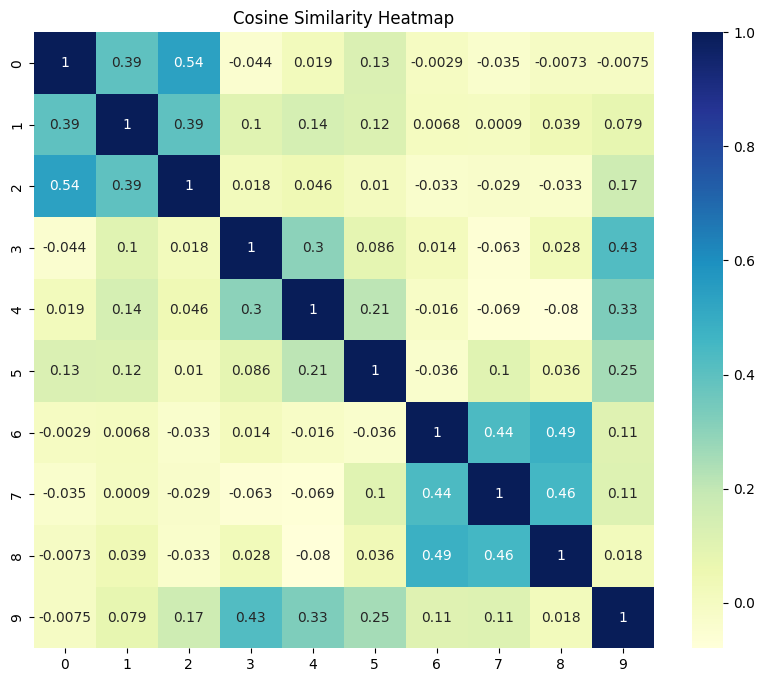

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

cosine_sim = util.cos_sim(embeddings, embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(cosine_sim.cpu().numpy(), annot=True, cmap="YlGnBu")
plt.title("Cosine Similarity Heatmap")
plt.show()


In [5]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

similarities = util.cos_sim(query_embedding, embeddings)[0]
top_results = similarities.topk(2)

print("Query:", query)
for idx, score in zip(top_results.indices, top_results.values):
    print(f"Sentence: {sentences[idx]} | Similarity: {score:.4f}")


Query: The bowler took three wickets in one over
Sentence: The batsman scored a century in the match. | Similarity: 0.5611
Sentence: The bowler delivered a fast yorker. | Similarity: 0.5414
